<a href="https://colab.research.google.com/github/Desmond-Tiny/Deep-Learning/blob/main/microsoft_stock_prediction_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
t=np.arange(0,1500)
x=np.sin(0.02*t)+np.random.rand(1500)*2


In [ ]:
x

array([1.41497782, 0.40784639, 1.73851107, ..., 0.33534718, 0.55583722,
       0.49277   ])

In [ ]:
train,test = x[0:1000],x[1000:]

In [ ]:
def convert_data_extra(data,x_step,y_step):
  X,Y = [],[]
  for i in range(len(data)-x_step-y_step+1):
    d=i+x_step

    X.append(data[i:d])
    Y.append(data[d:d+y_step])

  return np.array(X),np.array(Y)

x_step=6
y_step=1
trainX,trainY=convert_data_extra(train,x_step,y_step)
testX,testY=convert_data_extra(test,x_step,y_step)

trainX[1],testX[1]






(array([1.94391614, 1.32977149, 1.95433091, 0.86204971, 0.9209986 ,
        0.36208096]),
 array([0.93778679, 1.37043707, 1.23810476, 2.4071792 , 2.51664099,
        1.59877025]))

In [ ]:
trainX.shape,testX.shape

((994, 6), (494, 6))

In [ ]:
trainX=np.reshape(trainX,(trainX.shape[0],trainX.shape[1],1))
testX=np.reshape(testX,(testX.shape[0],testX.shape[1],1))

trainX.shape,testX.shape





((994, 6, 1), (494, 6, 1))

In [ ]:
trainY.shape

(994, 1)

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

ms=yf.download('MSFT',start='2012-01-01',end='2023-12-31',progress=False)


In [ ]:
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,26.549999,26.959999,26.389999,26.770000,21.200512,64731500
2012-01-04,26.820000,27.469999,26.780001,27.400000,21.699438,80516100
2012-01-05,27.379999,27.730000,27.290001,27.680000,21.921196,56081400
2012-01-06,27.530001,28.190001,27.530001,28.110001,22.261721,99455500
2012-01-09,28.049999,28.100000,27.719999,27.740000,21.968708,59706800


In [ ]:
ms[:"2021"].Close.values.reshape(-1,1).shape

(2517, 1)

In [ ]:
train=ms[:"2021"].Close.values.reshape(-1,1)
test=ms["2022":].Close.values.reshape(-1,1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
train=scaler.fit_transform(train)
test=scaler.transform(test)

In [ ]:
x_step=10
y_step=1

In [ ]:
def convert_data_extra(data,x_step,y_step):
  X,Y = [],[]
  for i in range(len(data)-x_step-y_step+1):
    d=i+x_step

    X.append(data[i:d])
    Y.append(data[d:d+y_step])

  return np.array(X),np.array(Y)

x_step=10
y_step=1
trainX,trainY=convert_data_extra(train,x_step,y_step)
testX,testY=convert_data_extra(test,x_step,y_step)


trainX.shape,testX.shape



((2507, 10, 1), (491, 10, 1))

In [ ]:
trainX=np.reshape(trainX,(trainX.shape[0],trainX.shape[1],1))
testX=np.reshape(testX,(testX.shape[0],testX.shape[1],1))

trainX.shape,testX.shape


((2507, 10, 1), (491, 10, 1))

In [ ]:
1from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN


model = Sequential()
model.add(SimpleRNN(units=64,activation='tanh',input_shape=(None,1),return_sequences=True))
model.add(SimpleRNN(units=64,activation='tanh'))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='rmsprop')

history = model.fit(trainX,trainY,epochs=100,batch_size=16)


score=model.evaluate(trainX,trainY)
print('train score',score)
score=model.evaluate(testX,testY)
print('test score',score)



Epoch 1/100
157/157 [==============================] - 4s 11ms/step - loss: 0.0152
Epoch 2/100
157/157 [==============================] - 2s 11ms/step - loss: 0.0017
Epoch 3/100
157/157 [==============================] - 1s 9ms/step - loss: 5.7923e-04
Epoch 4/100
157/157 [==============================] - 1s 7ms/step - loss: 3.6853e-04
Epoch 5/100
157/157 [==============================] - 1s 6ms/step - loss: 2.7532e-04
Epoch 6/100
157/157 [==============================] - 1s 6ms/step - loss: 2.1497e-04
Epoch 7/100
157/157 [==============================] - 1s 6ms/step - loss: 2.0040e-04
Epoch 8/100
157/157 [==============================] - 1s 6ms/step - loss: 1.7756e-04
Epoch 9/100
157/157 [==============================] - 1s 6ms/step - loss: 2.1951e-04
Epoch 10/100
157/157 [==============================] - 1s 6ms/step - loss: 1.5924e-04
Epoch 11/100
157/157 [==============================] - 1s 6ms/step - loss: 1.5854e-04
Epoch 12/100
157/157 [==============================] - 1s

In [ ]:
trainX.shape,testX.shape

((2507, 10, 1), (491, 10, 1))

In [ ]:
train_preds=model.predict(trainX)
test_preds=model.predict(testX)

16/16 [==============================] - 0s 3ms/step


In [ ]:
predicted=np.concatenate((train_preds,test_preds),axis=0)

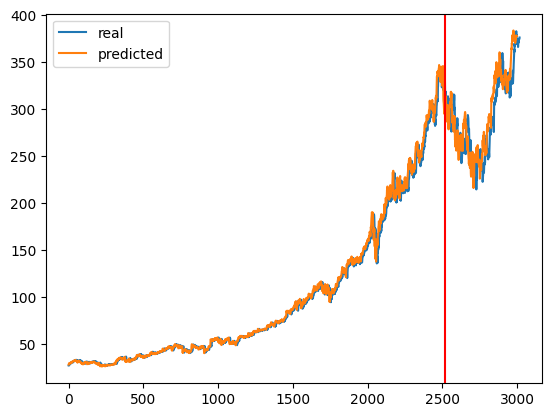

In [ ]:
plt.plot(ms.Close.values,label='real')
plt.plot(scaler.inverse_transform(predicted),label='predicted')
plt.axvline(x=len(train),c='r')
plt.legend()
plt.show()

In [ ]:
# train this with y_step=2 *

In [ ]:
preds=model.predict(testX)
preds.shape

16/16 [==============================] - 0s 3ms/step


(491, 1)